# ¿Una máquina lee tu radiografía dental mejor que el dentista?

Cuando un radiólogo escribe el reporte de una panorámica dental, se enfoca en lo que te llevó a la consulta. Lo demás —una caries incipiente en la esquina opuesta, una muela que viene torcida por debajo de la encía— muchas veces no llega al papel. No por descuido: por tiempo.

DentFound es un modelo de IA que aprendió de **101.000 pacientes** y escribe el reporte completo de una panorámica. Vamos a abrir los datos del paper y ver dos cosas: qué tan bien clasifica hallazgos frente a otros modelos, y qué pasa cuando lo comparan con un humano de carne y hueso.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Towards clinical-level interpretation of dental panoramic radiography using an instance-guided vision-language model*
**Journal:** Nature Biomedical Engineering (2026) · Zhu et al.
**DOI:** [10.1038/s41551-026-01713-8](https://doi.org/10.1038/s41551-026-01713-8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-26-dentfound-panoramica-dental/notebook.ipynb)

## Qué construyeron y por qué importa

Una radiografía panorámica es esa foto ancha que toma toda la boca de un lado a otro. Sirve para casi todo en odontología, pero interpretarla bien toma tiempo y hacen falta especialistas que escasean. El resultado: reportes incompletos, centrados en la queja principal, o que directamente no se hacen.

El equipo ensambló un dataset enorme —**101.000 pacientes**, de 2 a 98 años, con **98 enfermedades** y **11 categorías post-tratamiento**— y entrenó a DentFound, un modelo de visión y lenguaje (mira la imagen y escribe texto). Lo probaron en cuatro hospitales distintos y, además, lo pusieron cara a cara contra radiólogos humanos.

Un detalle importante desde ya: el título del paper dice *"towards clinical-level"* —*hacia* un nivel clínico—. Es un objetivo declarado, no un certificado. DentFound **no está aprobado para reemplazar a nadie en la consulta**; es una herramienta de apoyo. Con eso en mente, veamos los números.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MODELO_DESTACADO = 'DentFound'   # el modelo del paper
COLOR_DATOS      = '#2563EB'     # azul CaM (DentFound)
COLOR_RIVAL      = '#7C3AED'     # violeta (DentVLM, 2do mejor)
COLOR_HUMANO     = '#D97706'     # ámbar (radiólogo humano)
COLOR_DEBIL      = '#BBBBBB'     # gris (modelos más flojos)
FUENTE = 'Fuente: Zhu et al. (2026), Nature Biomedical Engineering · Datos: Source Data (figs. 2/4/6)'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 4 CSV del Source Data
bench = pd.read_csv('datos/benchmark_cohorts.csv')   # F1/Recall/Acc por cohorte x modelo
avh   = pd.read_csv('datos/ai_vs_human_report.csv')   # completitud DentFound vs Humano
exp   = pd.read_csv('datos/expert_ratings.csv')       # ratings subjetivos de expertos
abl   = pd.read_csv('datos/ablation_mask.csv')        # ablación de la máscara

print(f"Cohortes de evaluación : {bench['cohort'].nunique()}  ->  {list(bench['cohort'].unique())}")
print(f"Modelos comparados     : {bench['model'].nunique()}  ->  {list(bench['model'].unique())}")
print(f"Pacientes por cohorte  : {dict(bench.groupby('cohort')['sample_number'].first())}")
print(f"Métricas AI vs Humano  : {list(avh['metric'].unique())}")
print(f"Grupos de expertos     : {list(exp['rater_group'].unique())}")

Cohortes de evaluación : 4  ->  ['Internal cohort', 'ASH', 'SRH', 'YSH']
Modelos comparados     : 4  ->  ['BiomedGPT', 'DentVLM', 'Flamingo-CXF', 'DentFound']
Pacientes por cohorte  : {'ASH': np.int64(3838), 'Internal cohort': np.int64(56351), 'SRH': np.int64(5563), 'YSH': np.int64(4058)}
Métricas AI vs Humano  : ['Precision', 'Recall', 'F1-score']
Grupos de expertos     : ['Junior dentists', 'Junior radiologists', 'Senior dentists', 'Senior radiologists']


## Primera pregunta: ¿le gana a otros modelos?

Cuatro hospitales, cuatro modelos compitiendo. La métrica es el **F1-score**: combina qué tan preciso es (de lo que marca, cuánto acierta) con qué tan completo (de lo que hay, cuánto encuentra). Cuanto más alto, mejor.

Aquí está.

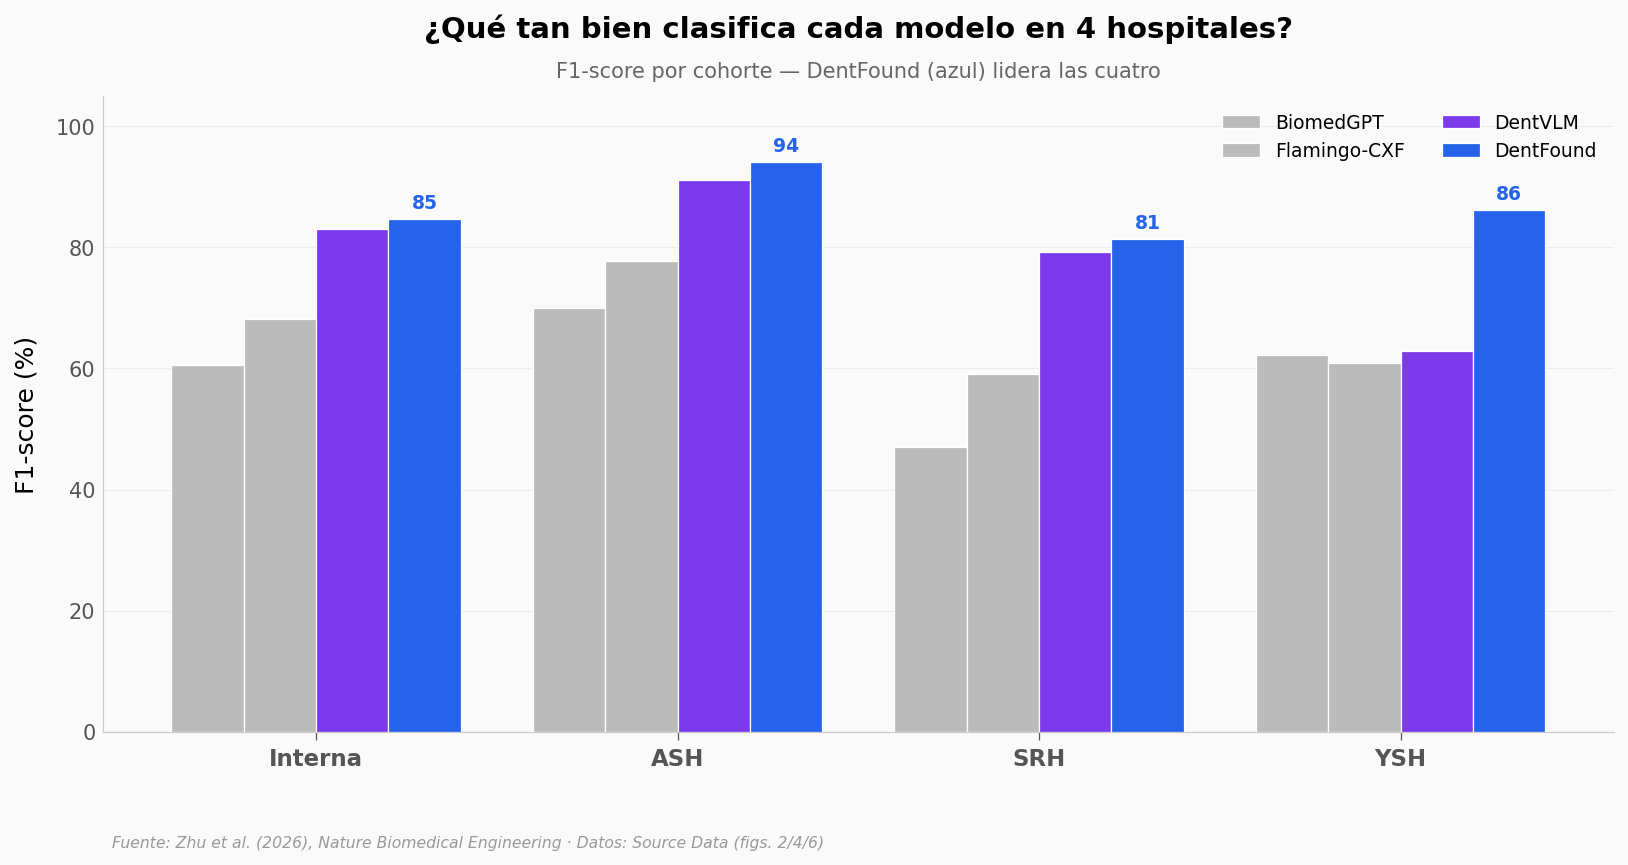

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

cohorts = ['Internal cohort', 'ASH', 'SRH', 'YSH']
cohort_labels = ['Interna', 'ASH', 'SRH', 'YSH']
models = ['BiomedGPT', 'Flamingo-CXF', 'DentVLM', 'DentFound']
colors = {'BiomedGPT': COLOR_DEBIL, 'Flamingo-CXF': COLOR_DEBIL,
          'DentVLM': COLOR_RIVAL, 'DentFound': COLOR_DATOS}

x = np.arange(len(cohorts))
w = 0.2
for i, m in enumerate(models):
    vals = [bench[(bench['cohort']==c) & (bench['model']==m)]['f1_pct'].values[0] for c in cohorts]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=m, color=colors[m],
                  edgecolor='white', linewidth=0.6,
                  zorder=5 if m=='DentFound' else 3)
    if m == 'DentFound':
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}', ha='center',
                    va='bottom', fontsize=9, fontweight='bold', color=COLOR_DATOS)

ax.set_xticks(x)
ax.set_xticklabels(cohort_labels, fontsize=11, fontweight='bold')
ax.set_ylabel('F1-score (%)')
ax.set_ylim(0, 105)
ax.set_title('¿Qué tan bien clasifica cada modelo en 4 hospitales?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'F1-score por cohorte — DentFound (azul) lidera las cuatro',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_f1_cohortes.png', dpi=200, bbox_inches='tight')
plt.show()

DentFound queda primero en las cuatro cohortes: **84,78%** en la interna, **94,20%** en ASH, **81,42%** en SRH y **86,25%** en YSH. Ese "gana siempre" es real para las tres métricas: F1, Recall (cuánto encuentra) y exactitud (accuracy).

Pero conviene mirar el margen, no solo el podio. Frente al segundo mejor —DentVLM— la ventaja es modesta en tres de los cuatro hospitales: **+1,8 puntos** en la interna, **+3,1** en ASH, **+2,2** en SRH. La excepción es YSH, donde DentFound saca **+23,3 puntos**: ahí DentVLM se desploma y el resto también. La distancia contra el modelo más flojo (BiomedGPT) sí es amplia en todos lados: entre 24 y 34 puntos.

Traducido: DentFound es consistentemente el mejor, pero en condiciones parecidas a las de entrenamiento su ventaja sobre un buen rival es de un par de puntos. Donde de verdad se separa es cuando el hospital es más raro (YSH) y los otros modelos flaquean.

## Segunda pregunta: ¿le gana a un humano?

Ganarle a otros modelos es una cosa. La comparación que importa clínicamente es contra un radiólogo. El equipo midió la **completitud** de los reportes: de todos los hallazgos que realmente estaban en la radiografía, ¿cuántos capturó cada uno?

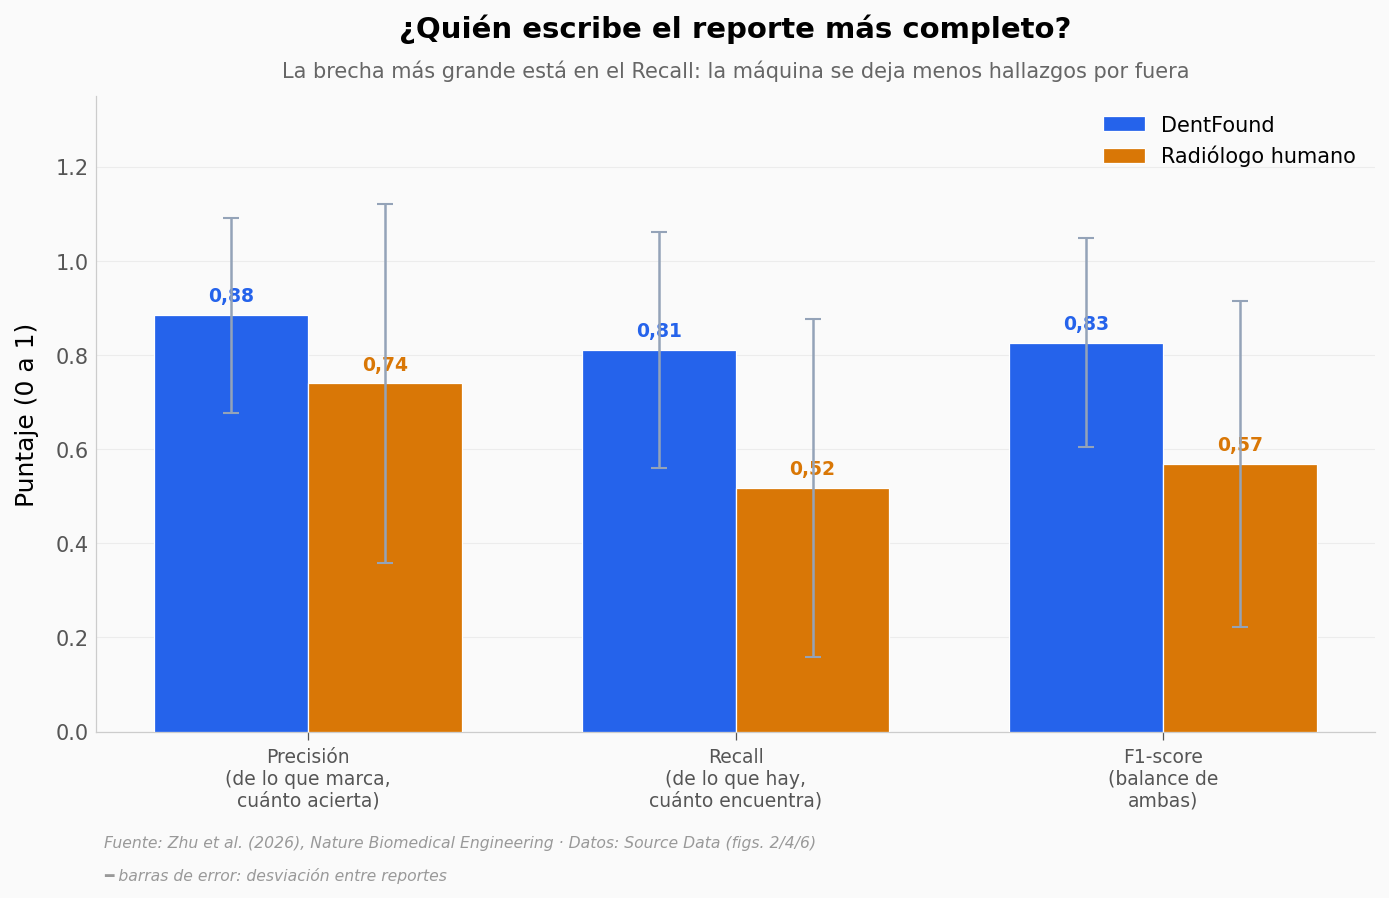

Precision : DentFound 0.884 vs Humano 0.740  |  +19.6% relativo  |  Cohen's d ≈ 0.47
Recall    : DentFound 0.811 vs Humano 0.518  |  +56.6% relativo  |  Cohen's d ≈ 0.94
F1-score  : DentFound 0.827 vs Humano 0.568  |  +45.5% relativo  |  Cohen's d ≈ 0.89


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

metrics = ['Precision', 'Recall', 'F1-score']
metric_labels = ['Precisión\n(de lo que marca,\ncuánto acierta)',
                 'Recall\n(de lo que hay,\ncuánto encuentra)',
                 'F1-score\n(balance de\nambas)']
x = np.arange(len(metrics))
w = 0.36

df_vals = [avh[(avh['who']=='DentFound') & (avh['metric']==m)]['mean'].values[0] for m in metrics]
df_sd   = [avh[(avh['who']=='DentFound') & (avh['metric']==m)]['sd'].values[0] for m in metrics]
hu_vals = [avh[(avh['who']=='Human') & (avh['metric']==m)]['mean'].values[0] for m in metrics]
hu_sd   = [avh[(avh['who']=='Human') & (avh['metric']==m)]['sd'].values[0] for m in metrics]

ax.bar(x - w/2, df_vals, w, yerr=df_sd, label='DentFound', color=COLOR_DATOS,
       edgecolor='white', linewidth=0.6, capsize=4,
       error_kw=dict(ecolor='#94a3b8', lw=1.2), zorder=5)
ax.bar(x + w/2, hu_vals, w, yerr=hu_sd, label='Radiólogo humano', color=COLOR_HUMANO,
       edgecolor='white', linewidth=0.6, capsize=4,
       error_kw=dict(ecolor='#94a3b8', lw=1.2), zorder=5)

for xi, (dv, hv) in enumerate(zip(df_vals, hu_vals)):
    ax.text(xi - w/2, dv + 0.02, f'{dv:.2f}'.replace('.', ','), ha='center',
            va='bottom', fontsize=9, fontweight='bold', color=COLOR_DATOS)
    ax.text(xi + w/2, hv + 0.02, f'{hv:.2f}'.replace('.', ','), ha='center',
            va='bottom', fontsize=9, fontweight='bold', color=COLOR_HUMANO)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylabel('Puntaje (0 a 1)')
ax.set_ylim(0, 1.35)
ax.set_title('¿Quién escribe el reporte más completo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La brecha más grande está en el Recall: la máquina se deja menos hallazgos por fuera',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
fig.text(0.13, -0.07, '━ barras de error: desviación entre reportes',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ai_vs_humano_completitud.png', dpi=200, bbox_inches='tight')
plt.show()

# Cohen's d a partir de media y desviación (referencia — sin n exacto por reporte)
for m in metrics:
    d_m = avh[(avh['who']=='DentFound') & (avh['metric']==m)]
    h_m = avh[(avh['who']=='Human') & (avh['metric']==m)]
    pooled = np.sqrt((d_m['sd'].values[0]**2 + h_m['sd'].values[0]**2) / 2)
    d = (d_m['mean'].values[0] - h_m['mean'].values[0]) / pooled
    rel = (d_m['mean'].values[0] - h_m['mean'].values[0]) / h_m['mean'].values[0] * 100
    print(f"{m:10s}: DentFound {d_m['mean'].values[0]:.3f} vs Humano {h_m['mean'].values[0]:.3f}  |  +{rel:.1f}% relativo  |  Cohen's d ≈ {d:.2f}")

En completitud la diferencia es clara y grande. El **Recall** de DentFound es **0,811** contra **0,518** del humano: un **+56,6%** relativo (Cohen's d ≈ 0,94, un efecto grande). En F1 la ventaja es **+45,5%** (d ≈ 0,89). La lectura es directa: el humano, presionado por el tiempo, escribe sobre la queja principal y se deja hallazgos incidentales por fuera. La máquina no se cansa y los lista todos.

Fíjate en las barras de error: son anchas, sobre todo las del humano. Hay reportes humanos muy completos y otros muy escuetos. La ventaja de DentFound es en promedio, no en cada caso.

Y aquí viene lo incómodo. "Más completo" no es lo mismo que "mejor". ¿Qué pasa cuando en vez de contar hallazgos le pides a un panel de expertos que juzgue la calidad del reporte?

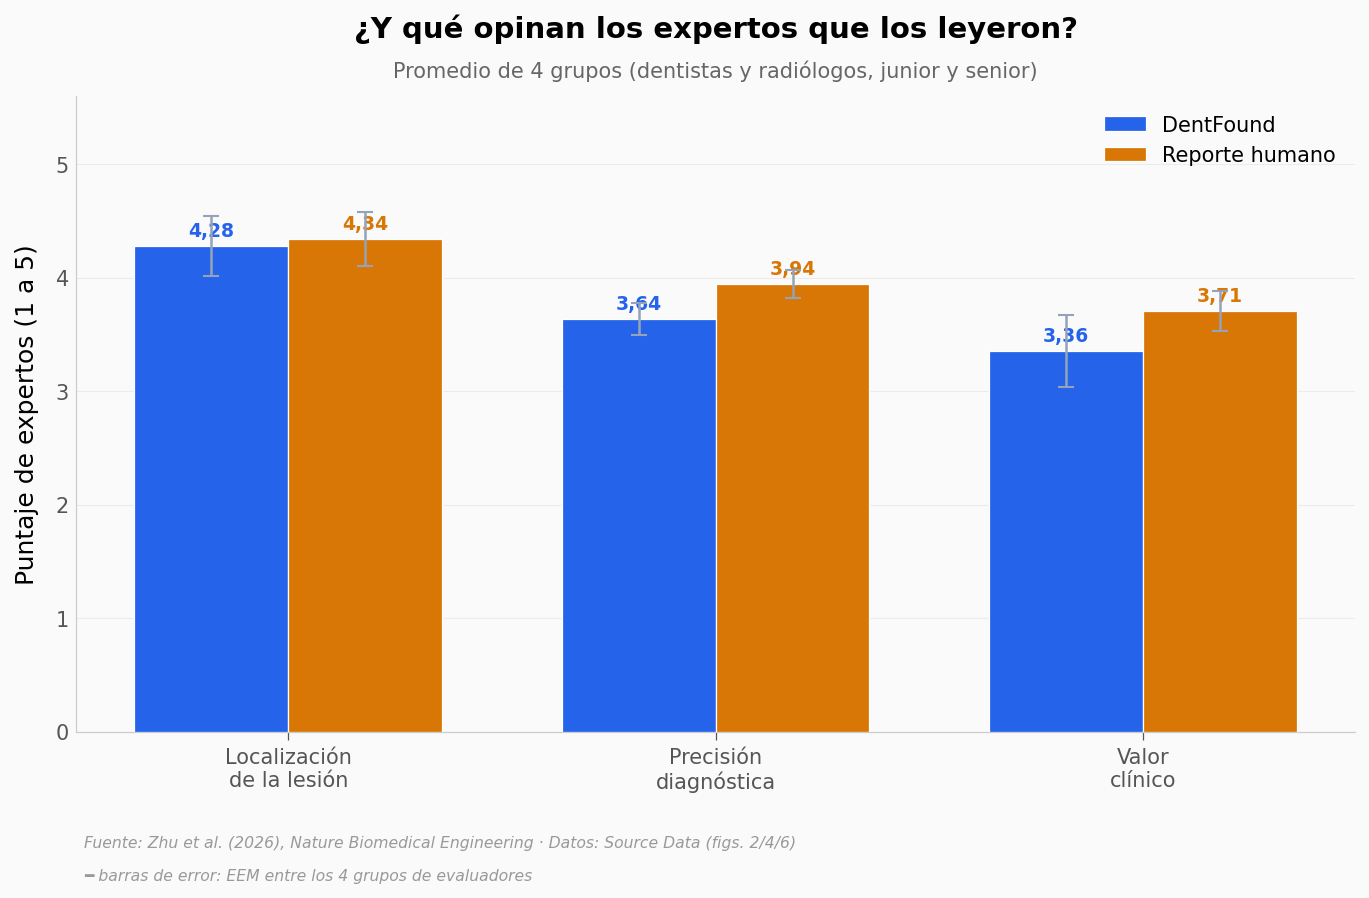

AI ≥ Humano en 2 de 12 pares (grupo x dimensión)


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

dims = ['lesion_localization', 'diagnosis_accuracy', 'clinical_value']
dim_labels = ['Localización\nde la lesión', 'Precisión\ndiagnóstica', 'Valor\nclínico']
x = np.arange(len(dims))
w = 0.36

ai_mean = [exp[exp['source']=='AI'][d].mean() for d in dims]
ai_sem  = [exp[exp['source']=='AI'][d].std(ddof=1)/np.sqrt(len(exp[exp['source']=='AI'])) for d in dims]
hu_mean = [exp[exp['source']=='Human'][d].mean() for d in dims]
hu_sem  = [exp[exp['source']=='Human'][d].std(ddof=1)/np.sqrt(len(exp[exp['source']=='Human'])) for d in dims]

ax.bar(x - w/2, ai_mean, w, yerr=ai_sem, label='DentFound', color=COLOR_DATOS,
       edgecolor='white', linewidth=0.6, capsize=4,
       error_kw=dict(ecolor='#94a3b8', lw=1.2), zorder=5)
ax.bar(x + w/2, hu_mean, w, yerr=hu_sem, label='Reporte humano', color=COLOR_HUMANO,
       edgecolor='white', linewidth=0.6, capsize=4,
       error_kw=dict(ecolor='#94a3b8', lw=1.2), zorder=5)

for xi, (av, hv) in enumerate(zip(ai_mean, hu_mean)):
    ax.text(xi - w/2, av + 0.05, f'{av:.2f}'.replace('.', ','), ha='center',
            va='bottom', fontsize=9, fontweight='bold', color=COLOR_DATOS)
    ax.text(xi + w/2, hv + 0.05, f'{hv:.2f}'.replace('.', ','), ha='center',
            va='bottom', fontsize=9, fontweight='bold', color=COLOR_HUMANO)

ax.set_xticks(x)
ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylabel('Puntaje de expertos (1 a 5)')
ax.set_ylim(0, 5.6)
ax.set_title('¿Y qué opinan los expertos que los leyeron?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Promedio de 4 grupos (dentistas y radiólogos, junior y senior)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
fig.text(0.13, -0.07, '━ barras de error: EEM entre los 4 grupos de evaluadores',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ratings_expertos.png', dpi=200, bbox_inches='tight')
plt.show()

# Conteo de pares donde AI >= Humano (4 grupos x 3 dimensiones)
pares = 0; total = 0
for _, g in exp.groupby('rater_group'):
    for d in dims:
        total += 1
        if g[g['source']=='AI'][d].values[0] >= g[g['source']=='Human'][d].values[0]:
            pares += 1
print(f"AI ≥ Humano en {pares} de {total} pares (grupo x dimensión)")

En el juicio subjetivo, el humano queda ligeramente arriba en las tres dimensiones: localización de la lesión (**4,34** vs 4,28), precisión diagnóstica (**3,94** vs 3,64) y valor clínico (**3,71** vs 3,36). De 12 comparaciones (4 grupos × 3 dimensiones), DentFound solo empata o supera al humano en **2**. La brecha es pequeña —del orden de 0,3 sobre 5— pero consistente.

Así que la frase del abstract, *"superior or comparable to human"*, es literal: **superior en completitud objetiva, comparable-pero-un-pelo-por-debajo en la valoración de los expertos**. No es "la IA reemplaza al radiólogo"; es "la IA no se deja nada por fuera, y el humano todavía redacta con un poco más de criterio clínico".

Última parada: ¿qué es lo que hace que DentFound funcione? Los autores señalan una pieza —la *guía por instancias*— y la probaron quitándola.

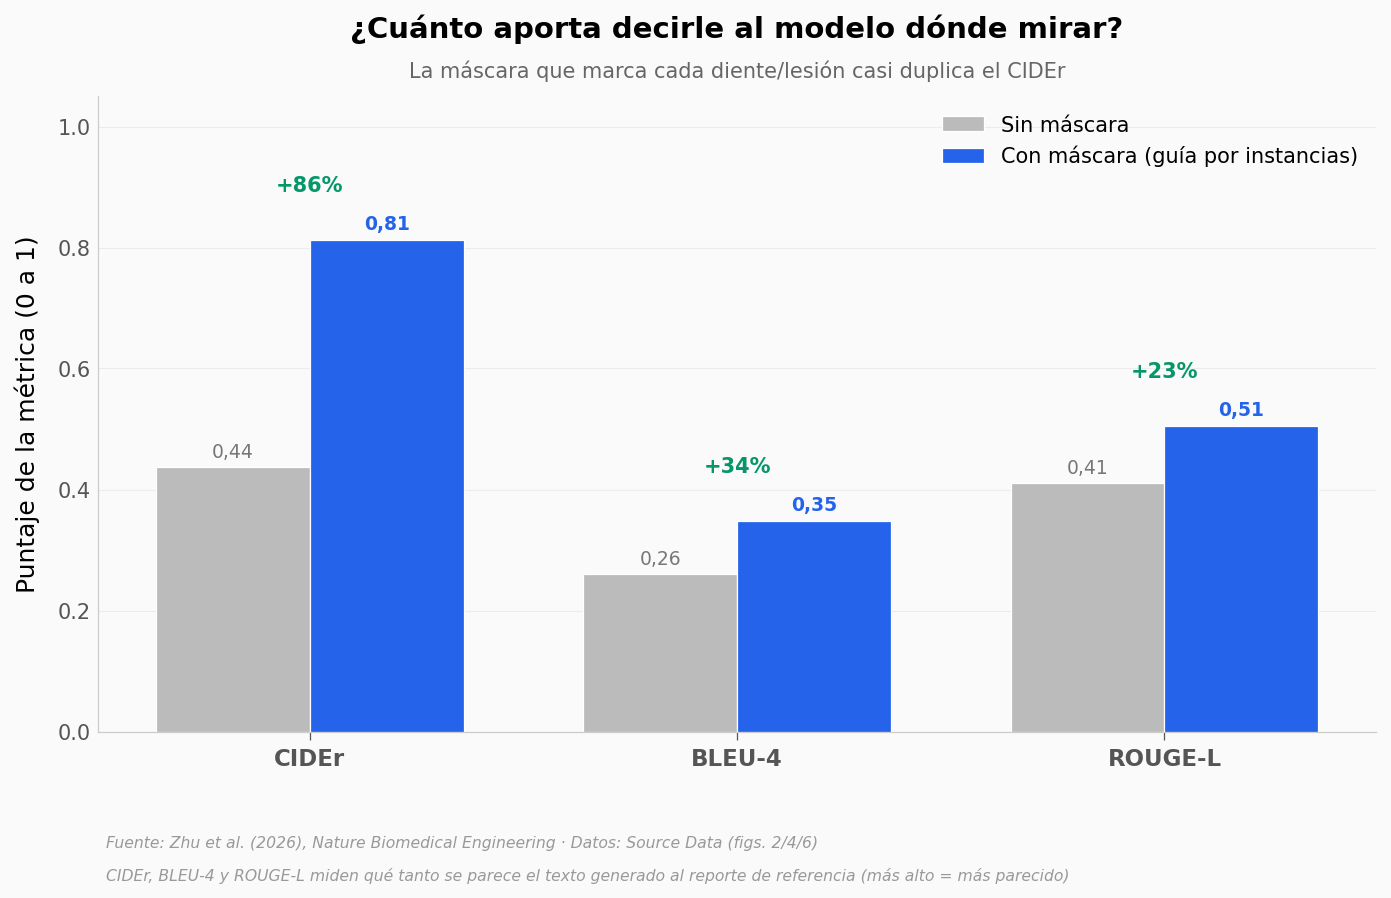

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

metrics = list(abl['metric'])          # CIDEr, BLEU-4, ROUGE-L
x = np.arange(len(metrics))
w = 0.36

sin_m = abl['without_mask'].values
con_m = abl['with_mask'].values

ax.bar(x - w/2, sin_m, w, label='Sin máscara', color=COLOR_DEBIL,
       edgecolor='white', linewidth=0.6, zorder=3)
ax.bar(x + w/2, con_m, w, label='Con máscara (guía por instancias)', color=COLOR_DATOS,
       edgecolor='white', linewidth=0.6, zorder=5)

for xi, (s, c) in enumerate(zip(sin_m, con_m)):
    ax.text(xi - w/2, s + 0.01, f'{s:.2f}'.replace('.', ','), ha='center',
            va='bottom', fontsize=9, color='#777777')
    ax.text(xi + w/2, c + 0.01, f'{c:.2f}'.replace('.', ','), ha='center',
            va='bottom', fontsize=9, fontweight='bold', color=COLOR_DATOS)
    subida = (c - s) / s * 100
    ax.annotate(f'+{subida:.0f}%'.replace('.', ','), xy=(xi, max(s, c) + 0.08),
                ha='center', fontsize=10, fontweight='bold', color='#059669')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax.set_ylabel('Puntaje de la métrica (0 a 1)')
ax.set_ylim(0, 1.05)
ax.set_title('¿Cuánto aporta decirle al modelo dónde mirar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La máscara que marca cada diente/lesión casi duplica el CIDEr',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
fig.text(0.13, -0.07, 'CIDEr, BLEU-4 y ROUGE-L miden qué tanto se parece el texto generado al reporte de referencia (más alto = más parecido)',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ablacion_mascara.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| DentFound queda #1 en F1/Recall/Accuracy en las 4 cohortes | ✅ | Se cumple en las 4/4. Pero el margen sobre el 2do (DentVLM) es de +1,8 a +3,1 pp en tres cohortes; solo en YSH es amplio (+23,3 pp). |
| Es más **completo** que el reporte humano | ✅ | Recall 0,811 vs 0,518 (+56,6%, Cohen's d ≈ 0,94); F1 +45,5% (d ≈ 0,89). Efecto grande y consistente. |
| Es **mejor** que el humano en general | ⚠️ | Solo en completitud objetiva. En ratings subjetivos de expertos el humano queda arriba en 10 de 12 pares (brecha ~0,3/5). El abstract dice "superior *or comparable*" — literal. |
| La "guía por instancias" (máscara) es clave | ✅ | Quitarla baja CIDEr un 46% (0,81 → 0,44). Con máscara: +86,1% CIDEr, +34,1% BLEU-4, +23,2% ROUGE-L. |
| DentFound "diagnostica" a nivel clínico | ❌ | Es apoyo diagnóstico, no diagnóstico certificado. El título dice *"towards"* (hacia). No está aprobado para uso clínico real. |

> **Limitaciones:** (1) Cohen's d se estimó a partir de media y desviación de los reportes, sin el *n* exacto por reporte — es una referencia del tamaño del efecto, no un test formal. (2) Las imágenes clínicas de los hospitales **no son públicas** (privacidad); estos CSV vienen del Source Data de las figuras (revisado por pares), no del corpus de imágenes. (3) CIDEr/BLEU-4/ROUGE-L miden solape de texto con un reporte de referencia; premian coincidir con ese estilo, no necesariamente el acierto clínico. (4) El paper también reporta categorías post-tratamiento donde DentVLM supera a DentFound en algunas — o sea, "gana siempre" aplica a estas métricas, no a absolutamente todo.

## Ahora tú

Los datos están cargados en `bench`, `avh`, `exp` y `abl`. Tres preguntas para hurgar:

1. **¿En qué hospital es más pareja la pelea?** Calcula, cohorte por cohorte, la diferencia de F1 entre DentFound y el segundo mejor. ¿Confirmas que YSH es el caso raro? *Pista: `bench.groupby('cohort')` y ordena los `f1_pct`.*

2. **¿El humano gana en algún grupo de expertos?** Mira `exp`: ¿hay algún grupo (junior/senior, dentista/radiólogo) donde DentFound quede por encima en alguna dimensión? *Pista: compara filas `AI` vs `Human` por `rater_group`.*

3. **¿Cuál métrica gana más con la máscara?** En `abl`, calcula el aumento relativo de las tres métricas. ¿Por qué crees que CIDEr sube tanto más que ROUGE-L? *Pista: `(con - sin) / sin * 100`.*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿en qué grupo de expertos DentFound iguala o supera al humano?
dims = ['lesion_localization', 'diagnosis_accuracy', 'clinical_value']
print('Casos donde DentFound (AI) ≥ humano:')
print('-' * 55)
for grupo, g in exp.groupby('rater_group'):
    ai = g[g['source'] == 'AI']
    hu = g[g['source'] == 'Human']
    for d in dims:
        a = ai[d].values[0]
        h = hu[d].values[0]
        if a >= h:
            print(f"  {grupo:20s} | {d:22s} : AI {a:.2f} ≥ Humano {h:.2f}")
print('-' * 55)
print('El resto de los 12 pares favorece al humano — por poco, pero de forma consistente.')

Casos donde DentFound (AI) ≥ humano:
-------------------------------------------------------
  Junior dentists      | clinical_value         : AI 4.07 ≥ Humano 4.03
  Senior radiologists  | lesion_localization    : AI 4.76 ≥ Humano 4.69
-------------------------------------------------------
El resto de los 12 pares favorece al humano — por poco, pero de forma consistente.


## Créditos y reproducibilidad

Este notebook es la extensión verificable de un video de **Ciencia a Mordiscos**. Todo el código y los datos están arriba: puedes reejecutarlo, cambiar los parámetros y llegar a los mismos números.

- **Paper:** *Towards clinical-level interpretation of dental panoramic radiography using an instance-guided vision-language model* — Zhu et al., Nature Biomedical Engineering (2026)
- **DOI:** [10.1038/s41551-026-01713-8](https://doi.org/10.1038/s41551-026-01713-8)
- **Código del modelo:** [github.com/ahukui/DentFound](https://github.com/ahukui/DentFound)
- **Datos:** Source Data del paper (figuras 2, 4 y 6). Las imágenes clínicas no son públicas por privacidad de pacientes.
- **Licencia:** notebook bajo la licencia del repositorio [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).

## Fuentes

**Paper**: [Towards clinical-level interpretation of dental panoramic radiography using an instance-guided vision-language model](https://doi.org/10.1038/s41551-026-01713-8)  
*Nature Biomedical Engineering, 2026-06-25 · Zhu et al.*

**Datos**: [Source Data del paper DentFound (benchmark multi-cohorte, evaluación AI vs humano, ablación instance-guidance)](https://doi.org/10.1038/s41551-026-01713-8)

**Código del modelo**: [github.com/ahukui/DentFound](https://github.com/ahukui/DentFound)

*13 afirmaciones del notebook verificadas contra estas fuentes*